# Feature Vectors, Problem Formulation, and Linear Algebra on Data

This notebook covers three connected ideas:

1. **Representation of data as feature vectors** — turning heterogeneous records into a design matrix $X \in \mathbb{R}^{n \times d}$.
2. **One dataset, two formulations** — the same $X$ used for a *regression* problem and a *classification* problem.
3. **Linear transformations and matrix–vector operations** — centering, scaling, rotation, projection (PCA), covariance and Gram matrices, and what these do to a fitted linear model.

Everything is written in plain NumPy so each matrix operation stays visible instead of hiding inside a library call.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

%matplotlib inline

np.random.seed(0)
np.set_printoptions(precision=3, suppress=True)
plt.rcParams["figure.figsize"] = (6, 4)
plt.rcParams["figure.dpi"] = 110

---
## Part 1 — Representation of data as feature vectors

Raw data arrives as heterogeneous records: numbers, strings, dates, categories. A learning
algorithm cannot consume a string; it needs each record encoded as a point $x \in \mathbb{R}^d$.

Stacking $n$ such row vectors gives the **design matrix**

$$
X = \begin{bmatrix} - & x_1^\top & - \\ & \vdots & \\ - & x_n^\top & - \end{bmatrix} \in \mathbb{R}^{n \times d}
$$

**Row = one sample. Column = one feature.** This convention matters: nearly every formula below
depends on it.

Our toy dataset is a table of apartments with three numeric fields and one categorical field.

In [2]:
RAW = [
    # area_m2, rooms, age_yrs, district, price_k_dolLar
    ( 52.0, 2, 12, "center",     210.0),
    ( 78.0, 3,  5, "center",     355.0),
    ( 95.0, 4, 30, "suburb",     240.0),
    ( 43.0, 1,  2, "center",     198.0),
    (120.0, 5, 18, "suburb",     330.0),
    ( 65.0, 3, 40, "industrial", 150.0),
    ( 88.0, 3,  9, "suburb",     285.0),
    ( 35.0, 1, 25, "industrial",  95.0),
    (110.0, 4,  3, "center",     495.0),
    ( 70.0, 2, 15, "suburb",     225.0),
    ( 58.0, 2, 35, "industrial", 130.0),
    (140.0, 5,  8, "center",     590.0),
]

pd.DataFrame(RAW, columns=["area_m2", "rooms", "age_yrs", "district", "price_k_dollar"])

,area_m2,rooms,age_yrs,district,price_k_dollar
0,52.0,2,12,center,210.0
1,78.0,3,5,center,355.0
2,95.0,4,30,suburb,240.0
3,43.0,1,2,center,198.0
4,120.0,5,18,suburb,330.0
5,65.0,3,40,industrial,150.0
6,88.0,3,9,suburb,285.0
7,35.0,1,25,industrial,95.0
8,110.0,4,3,center,495.0
9,70.0,2,15,suburb,225.0


### Encoding the categorical field

Numeric fields pass through unchanged. The `district` column cannot: mapping
`center -> 0, suburb -> 1, industrial -> 2` would invent an ordering and a distance
(`industrial` would be "twice" `suburb`) that do not exist in the data.

Instead each category becomes an **indicator vector** — a standard basis vector $e_k \in \{0,1\}^{|V|}$.
All categories then sit at equal distance $\sqrt{2}$ from each other.

In [3]:
NUMERIC_NAMES = ["area_m2", "rooms", "age_yrs"]
CATEGORIES = ["center", "suburb", "industrial"]
FEATURE_NAMES = NUMERIC_NAMES + [f"is_{c}" for c in CATEGORIES]


def one_hot(value, vocabulary):
    '''Categorical value -> indicator vector e_k in {0,1}^|V|.'''
    vec = np.zeros(len(vocabulary))
    vec[vocabulary.index(value)] = 1.0
    return vec


def encode(record):
    '''One raw record -> one feature vector x in R^d.'''
    area, rooms, age, district = record[0], record[1], record[2], record[3]
    numeric = np.array([area, rooms, age], dtype=float)
    return np.concatenate([numeric, one_hot(district, CATEGORIES)])


X = np.vstack([encode(r) for r in RAW])            # (n, d) design matrix
y_price = np.array([r[4] for r in RAW], float)     # (n,)   continuous target
n, d = X.shape

print(f"n = {n} samples, d = {d} features")
pd.DataFrame(X, columns=FEATURE_NAMES)

n = 12 samples, d = 6 features


,area_m2,rooms,age_yrs,is_center,is_suburb,is_industrial
0,52.0,2.0,12.0,1.0,0.0,0.0
1,78.0,3.0,5.0,1.0,0.0,0.0
2,95.0,4.0,30.0,0.0,1.0,0.0
3,43.0,1.0,2.0,1.0,0.0,0.0
4,120.0,5.0,18.0,0.0,1.0,0.0
5,65.0,3.0,40.0,0.0,0.0,1.0
6,88.0,3.0,9.0,0.0,1.0,0.0
7,35.0,1.0,25.0,0.0,0.0,1.0
8,110.0,4.0,3.0,1.0,0.0,0.0
9,70.0,2.0,15.0,0.0,1.0,0.0


In [4]:
print("x_1 (first sample, a point in R^6):", X[0])
print("column 'area_m2' (a feature across all samples):", X[:, 0])
print("target vector y:", y_price)
print("\nEuclidean distance between sample 1 and 2:", round(float(np.linalg.norm(X[0] - X[1])), 3))
print("Distance between two different one-hot districts:",
      round(float(np.linalg.norm(one_hot('center', CATEGORIES) - one_hot('suburb', CATEGORIES))), 3))

x_1 (first sample, a point in R^6): [52.  2. 12.  1.  0.  0.]
column 'area_m2' (a feature across all samples): [ 52.  78.  95.  43. 120.  65.  88.  35. 110.  70.  58. 140.]
target vector y: [210. 355. 240. 198. 330. 150. 285.  95. 495. 225. 130. 590.]

Euclidean distance between sample 1 and 2: 26.944
Distance between two different one-hot districts: 1.414


> **Note on the dummy variable trap.** The three one-hot columns sum to 1 in every row, so once we
> append an intercept column of ones, those four columns are linearly dependent and $\Phi^\top\Phi$
> becomes singular. Two standard fixes: drop one category level, or add a small ridge term.
> We use the ridge term below, and return to this point in Part 3.

---
## Part 2 — The same dataset as regression and as classification

$X$ does not change. **Only the target changes.**

| formulation | target | output space |
|---|---|---|
| regression | price in k DOLLAR | $y \in \mathbb{R}$ |
| classification | "is it expensive?" | $y \in \{0, 1\}$ |

Whether a problem is regression or classification is a *modelling decision*, not a property of the
data. Here we manufacture the classification labels by thresholding the regression target at its median.

In [5]:
threshold = np.median(y_price)
y_class = (y_price > threshold).astype(int)

pd.DataFrame({
    "y_reg (k DOLLAR)": y_price,
    f"y_cls (> {threshold})": y_class,
})

,y_reg (k DOLLAR),y_cls (> 232.5)
0,210.0,0
1,355.0,1
2,240.0,1
3,198.0,0
4,330.0,1
5,150.0,0
6,285.0,1
7,95.0,0
8,495.0,1
9,225.0,0


Thresholding **destroys information**: 198 and 590 both collapse to class 0 and 1 respectively based
only on which side of 232.5 they fall on, and the model can no longer tell a marginal case from an
extreme one. That is the price paid for the simpler output space.

### Preprocessing shared by both models

Two standard steps, both of them linear algebra:

- **Bias trick** — append a constant-1 column so the intercept becomes just another weight and the
  model is the single expression $\Phi w$.
- **Standardisation** — subtract the mean, divide by the standard deviation, so features with wildly
  different scales (area in the tens, rooms in the units) contribute comparably.

In [6]:
def add_bias(A):
    '''Append a constant-1 column: the intercept becomes just another weight.'''
    return np.hstack([np.ones((A.shape[0], 1)), A])


def standardize(A):
    '''Return standardised copy plus mu/sigma (needed to transform new data later).'''
    mu = A.mean(axis=0)
    sigma = A.std(axis=0)
    sigma[sigma == 0] = 1.0
    return (A - mu) / sigma, mu, sigma


Xs, mu, sigma = standardize(X)
Phi = add_bias(Xs)                    # (n, d+1)
print("Phi shape:", Phi.shape)
print("column means of Xs (~0):", Xs.mean(axis=0))
print("column stds  of Xs (~1):", Xs.std(axis=0))

Phi shape: (12, 7)
column means of Xs (~0): [ 0.  0.  0. -0.  0. -0.]
column stds  of Xs (~1): [1. 1. 1. 1. 1. 1.]


### 2a. Regression — least squares in closed form

**The goal in one sentence:** find one number (a *weight*) for each feature, so that
multiplying every feature by its weight and adding everything up lands as close as
possible to the true price.

For a single apartment $x$ with weights $w$ the prediction is just a dot product:

$$\hat{y} \;=\; w_0\cdot 1 \;+\; w_1\cdot \text{area} \;+\; w_2\cdot \text{rooms} \;+\; \dots \;=\; w \cdot x$$

For all $n$ apartments at once this becomes one matrix–vector product, $\hat{y} = \Phi w$.

**How do we choose $w$?** We pick the $w$ that makes the total squared mistake as small as
possible:

$$\text{cost}(w) \;=\; \lVert \Phi w - y \rVert^2 \;=\; \sum_{i=1}^{n}\big(\hat{y}_i - y_i\big)^2$$

Squaring does two things: it makes negative and positive errors both count as "bad", and it
punishes one large mistake more than several small ones.

**The good news:** unlike most models, this one does *not* need gradient descent. The cost is a
bowl-shaped (convex, quadratic) function, so the bottom of the bowl is where the gradient is
zero — and setting the gradient to zero gives a plain linear system, the **normal equations**:

$$(\Phi^\top \Phi)\, w \;=\; \Phi^\top y$$

Read that as: *"unknown vector $w$, times a known square matrix, equals a known vector."*
That is exactly what `np.linalg.solve` is for. Everything below is just building those two
ingredients and handing them to the solver.

| symbol | code | shape here | plain meaning |
|---|---|---|---|
| $\Phi$ | `Phi` | (12, 7) | one row per apartment, one column per feature (+ bias) |
| $y$ | `y_price` | (12,) | the true price of each apartment |
| $\Phi^\top\Phi$ | `Phi.T @ Phi` | (7, 7) | how each feature relates to every other feature |
| $\Phi^\top y$ | `Phi.T @ y_price` | (7,) | how each feature relates to the price |
| $w$ | `w_reg` | (7,) | the answer we are solving for |
> **What this method is called.** *Multiple linear regression*, solved in closed form via the
> normal equations, with a small ridge penalty. "Multiple" = many features (one feature would be
> *simple* linear regression; *multivariate* conventionally means many **targets**, which is not
> what we have). Strictly the ridge term makes this *ridge regression*; at `lam = 1e-3` it is
> numerically almost identical to **ordinary least squares (OLS)**, and Part 3f fits the exact OLS
> version with no penalty at all.

#### Aside — what does the `@` symbol do?

`@` is Python's **matrix multiplication** operator (added in Python 3.5). Every `@` below means
the same thing: *multiply pairwise, then add up.* That final adding-up is the entire difference
between `@` and `*`.

- `*` multiplies matching entries and **keeps them separate**.
- `@` multiplies matching entries and **sums them into one number** (per output slot).

**The shape rule.** For `(n, k) @ (k, m)` the two inner numbers must match; they cancel, and the
result is `(n, m)`. If they don't match you get `ValueError: matmul: ... size k is different from j`
— and the fix is almost always a missing `.T`.

`@` only works on objects that implement it: NumPy arrays, pandas objects, PyTorch tensors. On a
plain Python list it raises `TypeError`. There is also an in-place version, `A @= B`.

In [7]:
# `@` (sum the products) versus `*` (keep the products separate)

A = np.array([[1, 2],
              [3, 4]])
v = np.array([10, 20])

print("A @ v ->", A @ v)          # 1*10 + 2*20 = 50,  3*10 + 4*20 = 110   -> 2 numbers
print("A * v ->\n", A * v)        # nothing is summed                       -> 4 numbers

# --- the shape rule on this notebook's own matrices -------------------------
print("\nPhi.T @ Phi    :", Phi.T.shape, "@", Phi.shape, "->", (Phi.T @ Phi).shape)
print("Phi.T @ y_price:", Phi.T.shape, "@", y_price.shape, "->", (Phi.T @ y_price).shape)
print("Phi   @ w      :", Phi.shape, "@ (7,) ->", (Phi @ np.zeros(7)).shape)
print("y     @ y      :", y_price.shape, "@", y_price.shape, "-> scalar:",
      round(float(y_price @ y_price), 1))

# what a mismatch looks like
try:
    Phi @ Phi                      # (12,7) @ (12,7): inner 7 and 12 do not match
except ValueError as e:
    print("\nPhi @ Phi raises ->", e)

A @ v -> [ 50 110]
A * v ->
 [[10 40]
 [30 80]]

Phi.T @ Phi    : (7, 12) @ (12, 7) -> (7, 7)
Phi.T @ y_price: (7, 12) @ (12,) -> (7,)
Phi   @ w      : (12, 7) @ (7,) -> (12,)
y     @ y      : (12,) @ (12,) -> scalar: 1149229.0

Phi @ Phi raises -> matmul: Input operand 1 has a mismatch in its core dimension 0, with gufunc signature (n?,k),(k,m?)->(n?,m?) (size 12 is different from 7)


**Line by line**

- `A @ v` — `(2,2) @ (2,)`. Row `[1, 2]` meets `[10, 20]`: `1*10 + 2*20 = 50`. Row `[3, 4]` gives
  `110`. Two rows in, two numbers out.
- `A * v` — no summing, so all four products survive. NumPy *broadcasts* `v` across both rows.
  This is the `*` vs `@` distinction you saw in Step 4: `Phi[i] * w_reg` shows the seven
  contributions, `Phi[i] @ w_reg` shows the single prediction they add up to.
- `Phi.T @ Phi` — `(7,12) @ (12,7)`. The `12`s match and cancel, leaving `(7,7)`.
- `Phi.T @ y_price` — `(7,12) @ (12,)`. NumPy treats the 1-D `y_price` as a column here, so the
  result is `(7,)`, a vector.
- `Phi @ np.zeros(7)` — `(12,7) @ (7,)` → `(12,)`, one prediction per apartment. Any weight vector
  of length 7 works; this is the shape of `Phi @ w_reg`.
- `y_price @ y_price` — two **1-D** arrays give a plain dot product, i.e. a single scalar. That is
  the trick behind `ss_res = residuals @ residuals` in Step 3: a vector dotted with itself is the
  sum of its squares.
- The `try/except` — `Phi @ Phi` puts `7` next to `12`, which cannot cancel. Reading this error as
  "my inner dimensions disagree, I probably forgot a `.T`" saves a lot of time.

> **Not to be confused with decorators.** `@` also has a completely unrelated meaning when it sits
> alone at the start of a line above a `def` or `class` — `@property`, `@staticmethod`. Position
> tells them apart: a decorator is a prefix on its own line, matrix multiplication sits *between*
> two operands.

In [8]:
# Step 0 — look at the two ingredients we already have from the cells above

print("Phi shape    :", Phi.shape)      # (n, d+1) = (12 apartments, 1 bias + 6 features)
print("y_price shape:", y_price.shape)  # (n,)     = one true price per apartment

print("\nRow 0 of Phi (apartment 1, standardised, bias first):", Phi[0].round(3))
print("True price of apartment 1                           :", y_price[0], "k DOLLAR")

Phi shape    : (12, 7)
y_price shape: (12,)

Row 0 of Phi (apartment 1, standardised, bias first): [ 1.    -0.893 -0.694 -0.392  1.183 -0.707 -0.577]
True price of apartment 1                           : 210.0 k DOLLAR


**Line by line**

- `print("Phi shape    :", Phi.shape)` — `.shape` returns the tuple `(rows, columns)`.
  Rows = samples (12 apartments), columns = 7 = the bias column + the 6 encoded features.
  Getting into the habit of printing shapes catches most matrix bugs before they happen.
- `print("y_price shape:", y_price.shape)` — `(12,)` with a trailing comma means a **1-D**
  array (a plain vector), not a 12×1 matrix. NumPy treats those differently.
- `Phi[0]` — row `0`, i.e. everything known about the first apartment. Its first entry is
  `1.0` (the bias), the rest are the standardised features.
- `.round(3)` — display only; it does not change the stored values.
- `y_price[0]` — the matching true answer for that same row. `Phi[i]` and `y_price[i]` must
  always refer to the same apartment; that alignment is what makes the fit meaningful.

In [9]:
# Step 1 — build the normal equations and solve them, one line at a time

lam = 1e-3                                  # ridge strength: a deliberately tiny number

A = Phi.T @ Phi                             # (7,12) @ (12,7) -> (7,7)  square, symmetric
b = Phi.T @ y_price                         # (7,12) @ (12,)  -> (7,)   right-hand side

I = np.eye(Phi.shape[1])                    # (7,7) identity matrix
A_ridge = A + lam * I                       # nudge the diagonal so A is safely invertible

w_reg = np.linalg.solve(A_ridge, b)         # solve  A_ridge @ w = b   for w

print("A shape:", A.shape, "| b shape:", b.shape, "| w_reg shape:", w_reg.shape)
print("\nsmallest eigenvalue of A         :", np.linalg.eigvalsh(A).min().round(6))
print("smallest eigenvalue of A + lam*I :", np.linalg.eigvalsh(A_ridge).min().round(6))
print("\nw_reg =", w_reg.round(3))

A shape: (7, 7) | b shape: (7,) | w_reg shape: (7,)

smallest eigenvalue of A         : -0.0
smallest eigenvalue of A + lam*I : 0.001

w_reg = [275.227 168.104 -48.744 -30.446  22.195 -25.324   2.299]


**Line by line**

- `lam = 1e-3` — the ridge strength $\lambda$. Recall the warning from Part 1: the three
  one-hot columns always sum to `1`, and the bias column *is* all ones, so those four columns
  are linearly dependent. That makes $\Phi^\top\Phi$ **singular** (not invertible) and the
  solver would either fail or return garbage. `lam` is the fix.
- `A = Phi.T @ Phi` — `Phi.T` transposes (7, 12); the `@` operator is matrix multiplication.
  Inner dimensions `12` cancel, leaving a **(7, 7)** matrix. Entry `A[i, j]` is the dot product
  of feature column `i` with feature column `j` — a summary of how the features overlap.
- `b = Phi.T @ y_price` — same transpose, now hitting the **vector** of prices, so the result is
  a **(7,)** vector. Entry `b[i]` says how strongly feature `i` moves together with price.
- `I = np.eye(7)` — the identity matrix: ones on the diagonal, zeros elsewhere.
- `A_ridge = A + lam * I` — adds `0.001` to each diagonal entry only. Geometrically it lifts the
  flat directions of the cost bowl just enough that a unique lowest point exists. Setting
  `lam = 0` here would make the next line blow up.
- `np.linalg.solve(A_ridge, b)` — solves the linear system for `w`. Use this rather than
  `np.linalg.inv(A_ridge) @ b`: it is faster and numerically more stable, because computing a
  full inverse throws away precision you do not need.
- `np.linalg.eigvalsh(...)` — eigenvalues of a symmetric matrix. The print makes the problem
  visible: the smallest eigenvalue of `A` is essentially `0` (singular), and after adding
  `lam * I` it is exactly `lam` larger — no longer zero, so the system is now solvable.

In [10]:
# Step 2 — the same four lines packed into a reusable function

def fit_ridge(Phi, y, lam=1e-3):
    """Closed-form ridge regression: returns the weight vector w."""
    A = Phi.T @ Phi + lam * np.eye(Phi.shape[1])   # (d+1, d+1) Gram matrix + ridge
    b = Phi.T @ y                                  # (d+1,)     matrix-vector product
    return np.linalg.solve(A, b)                   # (d+1,)     the fitted weights


w_check = fit_ridge(Phi, y_price)                  # should reproduce Step 1 exactly
print("function agrees with the manual version:", np.allclose(w_check, w_reg))

print("\nfitted weights:")
print(pd.Series(w_reg, index=["bias"] + FEATURE_NAMES, name="weight").round(3))

function agrees with the manual version: True

fitted weights:
bias             275.227
area_m2          168.104
rooms            -48.744
age_yrs          -30.446
is_center         22.195
is_suburb        -25.324
is_industrial      2.299
Name: weight, dtype: float64


**Line by line**

- `def fit_ridge(Phi, y, lam=1e-3):` — `lam` has a **default value**, so `fit_ridge(Phi, y)`
  works and `fit_ridge(Phi, y, lam=10)` overrides it.
- The body is Step 1 with `A` and the ridge term merged onto one line — nothing new happens.
- `np.allclose(w_check, w_reg)` — compares two float arrays with a small tolerance. Never use
  `==` on floats; rounding noise makes exact equality unreliable.
- `pd.Series(w_reg, index=["bias"] + FEATURE_NAMES)` — attaches a name to each number so the
  output is readable. `w_reg[0]` belongs to the bias column, `w_reg[1]` to `area_m2`, and so on.

**How to read the weights.** Because the features were standardised first, every weight answers
the same question: *"if this feature increases by one standard deviation and everything else stays
put, how many thousand dollars does the predicted price move?"* A positive weight pushes the price
up, a negative one pulls it down, and a weight near zero means that feature barely matters here.
Since all features now share one scale, the magnitudes are directly comparable — which would
**not** be true on the raw, unstandardised columns.

#### Aside — why do we add a bias term at all?

Look at the weight table above: `bias = 275.227`. Now compare it to `y_price.mean() = 275.25`.
That is not a coincidence, and the reason explains what the bias is for.

**The geometric reason.** Without a bias the model is $\hat{y} = w_1 x_1 + w_2 x_2 + \dots$ — plug
in zeros and you *necessarily* get zero. That set of predictions forms a **linear** subspace, and
every linear subspace passes through the origin. Adding the bias makes it **affine**: the same
hyperplane, but free to float up or down to wherever the data actually lives.

Two separate questions are being asked, and you need two kinds of parameter to answer them:

| parameter | question it answers |
|---|---|
| slopes $w_1 \dots w_d$ | *how fast* does price change as a feature changes? |
| bias $w_0$ | *where does the price start* when the features are at zero? |

Without $w_0$ the slopes have to distort themselves to compensate for a missing offset, and the
fit degrades badly — the cell below measures exactly how badly.

**Why append a column of ones instead of tracking $b$ separately?** You could write
$\hat{y} = Xw + b$ and carry `b` around as its own variable, but then every formula needs two
cases. Appending a constant-1 column turns the intercept into ordinary weight number zero, and the
whole model collapses to one expression, `Phi @ w`. The dot product does the rest: `1.0 * w_0`
contributes `w_0` to every single prediction — which is precisely what an intercept is.

bias weight w_reg[0] : 275.227
mean of y_price      : 275.250   <- the same number

RMSE    with bias :    16.92 k DOLLAR
RMSE without bias :   275.77 k DOLLAR

mean prediction without bias : -0.00   <- forced to zero


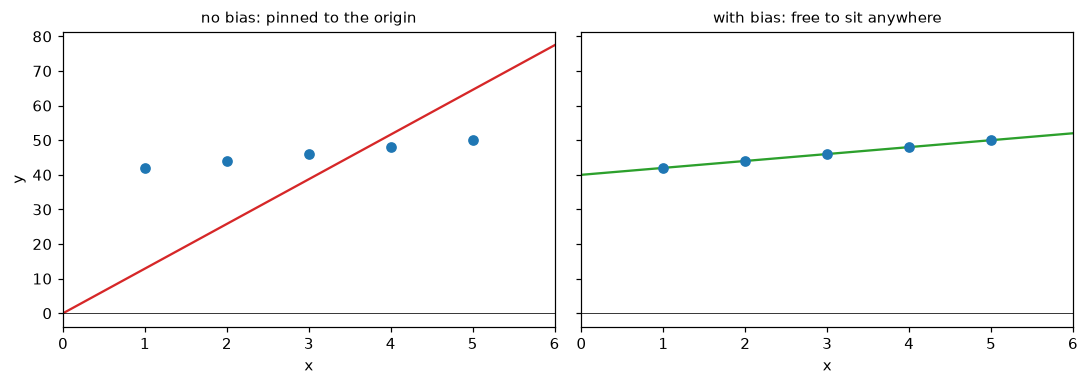

In [11]:
# Experiment — refit the model with the bias column removed

w_nobias = np.linalg.solve(Xs.T @ Xs + lam * np.eye(d), Xs.T @ y_price)   # no column of ones
pred_nobias = Xs @ w_nobias
pred_bias = Phi @ w_reg

rmse_of = lambda p: float(np.sqrt(np.mean((y_price - p) ** 2)))

print(f"bias weight w_reg[0] : {w_reg[0]:.3f}")
print(f"mean of y_price      : {y_price.mean():.3f}   <- the same number")
print()
print(f"RMSE    with bias : {rmse_of(pred_bias):8.2f} k DOLLAR")
print(f"RMSE without bias : {rmse_of(pred_nobias):8.2f} k DOLLAR")
print()
print(f"mean prediction without bias : {pred_nobias.mean():.2f}   <- forced to zero")

#the same idea on 1-D toy data, drawn
x_toy = np.array([1., 2., 3., 4., 5.])
y_toy = 2 * x_toy + 40                                  # a clear offset of 40

w_origin = (x_toy @ y_toy) / (x_toy @ x_toy)            # best line through (0, 0)
w_affine = np.linalg.lstsq(np.c_[np.ones(5), x_toy], y_toy, rcond=None)[0]

grid = np.linspace(0, 6, 50)
fig, axes = plt.subplots(1, 2, figsize=(10, 3.6), sharey=True)
for ax, (line, ttl) in zip(axes, [(w_origin * grid, "no bias: pinned to the origin"),
                                  (w_affine[0] + w_affine[1] * grid, "with bias: free to sit anywhere")]):
    ax.scatter(x_toy, y_toy, c="tab:blue", zorder=3)
    ax.plot(grid, line, color="tab:red" if "no bias" in ttl else "tab:green")
    ax.axhline(0, lw=.5, color="k"); ax.axvline(0, lw=.5, color="k")
    ax.set_xlim(0, 6); ax.set_title(ttl, fontsize=10); ax.set_xlabel("x")
axes[0].set_ylabel("y")
plt.tight_layout(); plt.show()

**Line by line**

- `np.linalg.solve(Xs.T @ Xs + lam*np.eye(d), Xs.T @ y_price)` — the same normal equations as
  Step 1, but built from `Xs` (6 columns) instead of `Phi` (7 columns). Dropping that one column
  of ones is the entire change.
- `rmse_of = lambda p: ...` — a one-line throwaway function so the two RMSEs are computed
  identically. A `lambda` is just a `def` without a name.
- The printed result: **RMSE jumps from about 17 to about 276 k DOLLAR** — the error becomes as
  large as the prices themselves. The model is useless.
- `pred_nobias.mean()` is `-0.00`, and it could not be anything else. `standardize` gave every
  column of `Xs` a mean of zero, so any weighted sum of those columns also has mean zero. The bias
  is the *only* parameter able to lift the predictions up to the ~275k range where the real prices
  sit. Everything the model was doing before was relative to that baseline.
- `w_origin = (x_toy @ y_toy) / (x_toy @ x_toy)` — the closed-form best slope when the intercept is
  forced to zero (the 1-D case of the normal equations, with no bias column).
- `np.c_[np.ones(5), x_toy]` — `np.c_` glues arrays together as columns; this is `add_bias` written
  inline for the toy data.
- The plot: same five points both times. On the left the line is nailed to `(0, 0)` and has to
  swing up through them at the wrong angle. On the right the intercept lets it sit at the right
  height, so the slope is free to describe the actual trend.

**One caveat about the ridge term.** `fit_ridge` uses `np.eye(7)`, which has a `1` in the top-left
corner — so the penalty shrinks the bias too. There is no good reason to prefer a model whose
baseline price is near zero, and proper implementations exclude the intercept. At `lam = 1e-3` the
distortion is invisible (0.023k, the small gap between 275.227 and 275.25), but the next cell shows
it clearly at a larger `lam`. The fix is one line:

```python
I = np.eye(Phi.shape[1])
I[0, 0] = 0.0          # do not regularise the intercept
```

In [12]:
# What the ridge penalty does to the bias, at two different strengths

for lam_try in (1e-3, 1.0, 100.0):
    I_pen = np.eye(Phi.shape[1])                     # penalises every weight, bias included
    I_free = np.eye(Phi.shape[1]); I_free[0, 0] = 0.0  # leaves the bias alone

    w_pen = np.linalg.solve(Phi.T @ Phi + lam_try * I_pen, Phi.T @ y_price)
    w_free = np.linalg.solve(Phi.T @ Phi + lam_try * I_free, Phi.T @ y_price)

    print(f"lam = {lam_try:>7}   bias penalised = {w_pen[0]:7.2f}   bias left free = {w_free[0]:7.2f}")

print(f"\nmean price (what the bias should be) = {y_price.mean():.2f}")

lam =   0.001   bias penalised =  275.23   bias left free =  275.25
lam =     1.0   bias penalised =  254.08   bias left free =  275.25
lam =   100.0   bias penalised =   29.49   bias left free =  275.25

mean price (what the bias should be) = 275.25


Read the last column: leaving the bias out of the penalty keeps it pinned at the mean price no
matter how strong the regularisation gets, which is the behaviour you want. The penalised column
drifts towards zero as `lam` grows — the model is being punished for admitting that apartments cost
money.

In [13]:
# Step 3 — predict, measure the error, score the fit

y_hat = Phi @ w_reg                         # (12,7) @ (7,) -> (12,)  all predictions at once
residuals = y_price - y_hat                 # what the model missed, per apartment

rmse = np.sqrt(np.mean(residuals ** 2))     # typical error, back in k DOLLAR units

ss_res = residuals @ residuals              # sum of squared errors of OUR model
ss_tot = (y_price - y_price.mean()) @ (y_price - y_price.mean())   # ... of "always guess the mean"
r2 = 1 - ss_res / ss_tot                    # fraction of the variance we explained

print(pd.DataFrame({
    "actual":    y_price.round(1),
    "predicted": y_hat.round(1),
    "residual":  residuals.round(1),
}))
print(f"\nRMSE = {rmse:.2f} k DOLLAR    R^2 = {r2:.3f}")

    actual  predicted  residual
0    210.0      213.7      -3.7
1    355.0      336.0      19.0
2    240.0      231.5       8.5
3    198.0      226.2     -28.2
4    330.0      360.6     -30.6
5    150.0      138.9      11.1
6    285.0      282.0       3.0
7     95.0       86.0       9.0
8    495.0      478.7      16.3
9    225.0      205.8      19.2
10   130.0      150.0     -20.0
11   590.0      593.3      -3.3

RMSE = 16.92 k DOLLAR    R^2 = 0.986


**Line by line**

- `y_hat = Phi @ w_reg` — the whole model in one symbol. Row `i` of `Phi` is dotted with `w_reg`,
  giving prediction `i`; doing all 12 rows at once is why matrix notation is worth learning.
  `y_hat` (read "y-hat") is the standard name for a predicted value.
- `residuals = y_price - y_hat` — element-wise subtraction. **Positive** = the model
  under-predicted (the flat was pricier than we said); **negative** = it over-predicted.
- `residuals ** 2` — squares each entry, so signs stop cancelling out.
  `np.mean(...)` averages them (that is the MSE), and `np.sqrt(...)` undoes the squaring so the
  number is back in thousands of dollars. **RMSE ≈ the typical size of a miss** — smaller is better.
- `ss_res = residuals @ residuals` — a dot product of a vector with itself is the sum of its
  squares, so this is the total squared error of our model.
- `ss_tot = (y_price - y_price.mean()) @ (...)` — the same total for the dumbest possible model:
  ignore every feature and always guess the average price. This is the baseline.
- `r2 = 1 - ss_res / ss_tot` — the **coefficient of determination**. If our error equals the
  baseline's, the ratio is 1 and $R^2 = 0$ (worthless). If our error is 0, $R^2 = 1$ (perfect).
  So $R^2$ is "what fraction of the price variation did the features explain?"
- The `pd.DataFrame({...})` puts actual, predicted and residual side by side so you can spot
  *which* apartments the model struggles with, not just the summary number.

One honest caveat: this is measured on the same 12 rows the model was fitted on, with 7
parameters. A flattering score here is expected — real evaluation needs held-out data.

In [14]:
# Step 4 — one prediction taken apart, so the dot product stops being abstract

i = 0                                       # apartment 1 (52 m2, 2 rooms, 12 yrs, center)

contribution = Phi[i] * w_reg               # ELEMENT-wise product: one term per feature

print(pd.DataFrame({
    "feature":      ["bias"] + FEATURE_NAMES,
    "value":        Phi[i].round(3),
    "weight":       w_reg.round(2),
    "contribution": contribution.round(2),
}))

print("\nsum of contributions :", contribution.sum().round(2))
print("Phi[i] @ w_reg       :", (Phi[i] @ w_reg).round(2))
print("actual price         :", y_price[i])

         feature  value  weight  contribution
0           bias  1.000  275.23        275.23
1        area_m2 -0.893  168.10       -150.14
2          rooms -0.694  -48.74         33.84
3        age_yrs -0.392  -30.45         11.93
4      is_center  1.183   22.19         26.26
5      is_suburb -0.707  -25.32         17.91
6  is_industrial -0.577    2.30         -1.33

sum of contributions : 213.7
Phi[i] @ w_reg       : 213.7
actual price         : 210.0


**Line by line**

- `contribution = Phi[i] * w_reg` — note the `*`, **not** `@`. A single `*` multiplies matching
  entries and keeps 7 separate numbers; `@` would immediately add them into one. Seeing them
  separately shows each feature's push on the final price.
- `contribution.sum()` versus `Phi[i] @ w_reg` — these print the same number, which is the whole
  point: **a dot product is nothing more than "multiply pairwise, then add up."**
- Compare that number to `y_price[i]`: the gap is exactly `residuals[i]` from the previous cell.

Reading the table top to bottom tells you the story of one prediction: the bias sets the starting
level, and each feature nudges it up or down by `value × weight`.

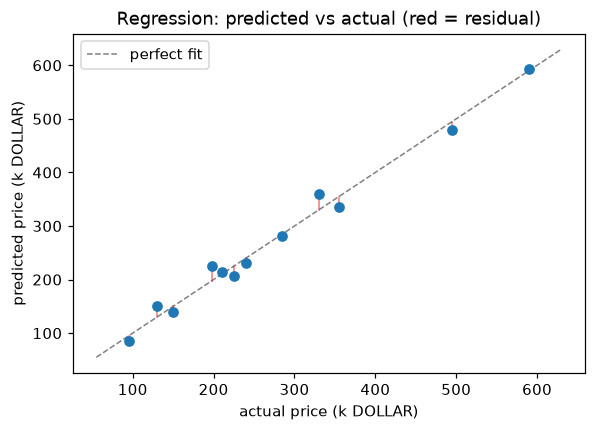

In [15]:
# Step 5 — the standard diagnostic plot: predicted vs actual

fig, ax = plt.subplots()                                    # one empty figure with one axes

lo, hi = y_price.min() - 40, y_price.max() + 40             # padded range for the diagonal
ax.plot([lo, hi], [lo, hi], "--", color="grey", lw=1,       # the y = x line: a perfect model
        label="perfect fit")

ax.scatter(y_price, y_hat, c="tab:blue", zorder=3)          # x = truth, y = prediction

for t, p in zip(y_price, y_hat):                            # t = true value, p = prediction
    ax.plot([t, t], [t, p], color="tab:red", lw=1, alpha=.6)  # vertical line = the residual

ax.set_xlabel("actual price (k DOLLAR)")
ax.set_ylabel("predicted price (k DOLLAR)")
ax.set_title("Regression: predicted vs actual (red = residual)")
ax.legend()
plt.show()

**Line by line**

- `fig, ax = plt.subplots()` — `fig` is the whole canvas, `ax` the single plotting area. Almost
  every matplotlib call below is a method on `ax`.
- `lo, hi = y_price.min() - 40, y_price.max() + 40` — the data range with 40k of padding, so the
  diagonal runs past the outermost points instead of stopping on top of them.
- `ax.plot([lo, hi], [lo, hi], "--", ...)` — draws the line from `(lo, lo)` to `(hi, hi)`, i.e.
  **y = x**: where every dot would sit if predictions were exact. `"--"` makes it dashed,
  `lw=1` sets the width, and `label=` feeds the legend.
- `ax.scatter(y_price, y_hat, ...)` — actual price on the x-axis, predicted on the y-axis.
  `zorder=3` draws the dots on top of the lines rather than under them.
- `for t, p in zip(y_price, y_hat):` — `zip` walks both arrays together, handing you each
  (truth, prediction) pair.
- `ax.plot([t, t], [t, p], ...)` — both x-coordinates are `t`, so the segment is vertical; it
  runs from the diagonal up or down to the dot. **Its length is the residual.**
  `alpha=.6` makes it slightly transparent so overlaps stay readable.
- `plt.show()` — renders the figure.

**Reading it:** dots above the dashed line were over-predicted, dots below were under-predicted,
and the length of the red stick is how wrong the model was on that apartment. A good fit hugs the
diagonal with short sticks scattered on both sides; a curved pattern, or sticks that grow steadily
towards one end, would be a hint that a straight-line model is the wrong shape for this data.

**Recap of the whole regression, in five lines of real work**

```python
A     = Phi.T @ Phi + lam * np.eye(Phi.shape[1])   # square matrix   (d+1, d+1)
b     = Phi.T @ y_price                            # vector          (d+1,)
w_reg = np.linalg.solve(A, b)                      # the fitted weights
y_hat = Phi @ w_reg                                # the predictions
rmse  = np.sqrt(np.mean((y_price - y_hat) ** 2))   # the error
```

No loops, no learning rate, no epochs — the optimum is available in closed form. Compare this with
2b below, where the sigmoid removes that luxury and the weights have to be found by iterating.

#### Aside — what "linear" actually means here

The word *linear* is the most misread part of the name. It means the model is linear **in the
weights $w$**, not in the features. `Phi @ w` is a weighted sum of columns — that is the entire
definition, and it says nothing about what those columns contain.

The consequence is bigger than it sounds: you can square a feature, take its log, multiply two
features together, or bucket a value into indicators, and the model is **still linear regression**.
Every formula in this notebook — the normal equations, `np.linalg.solve`, the whole derivation —
stays valid, because $w$ still enters linearly. This is called a **basis expansion**.

You have already done one without noticing: `is_center`, `is_suburb`, `is_industrial` are nonlinear
transformations of a raw string, and nothing broke. The cell below adds two more aggressive ones.

In [16]:
# Basis expansion — curved fits from the SAME linear machinery

X_poly = np.column_stack([
    Xs,                      # the 6 features we already had
    Xs[:, 0] ** 2,           # area squared        -> nonlinear in the FEATURE
    Xs[:, 0] * Xs[:, 1],     # area x rooms        -> an interaction term
])

Phi_poly = add_bias(X_poly)          # (12, 9)
w_poly = fit_ridge(Phi_poly, y_price)   # <- the SAME function, unchanged

rmse_of = lambda P, w: float(np.sqrt(np.mean((y_price - P @ w) ** 2)))

print("Phi      :", Phi.shape, "  RMSE =", round(rmse_of(Phi, w_reg), 2))
print("Phi_poly :", Phi_poly.shape, "  RMSE =", round(rmse_of(Phi_poly, w_poly), 2))

print("\nextra weights:")
print(pd.Series(w_poly[-2:], index=["area^2", "area x rooms"]).round(3))

Phi      : (12, 7)   RMSE = 16.92
Phi_poly : (12, 9)   RMSE = 12.27

extra weights:
area^2          38.984
area x rooms   -48.557
dtype: float64


**Line by line**

- `np.column_stack([...])` — glues arrays together as columns, the same job `np.c_` did earlier.
- `Xs[:, 0] ** 2` — column 0 (`area_m2`) squared, elementwise. The relationship between area and
  price is now allowed to curve.
- `Xs[:, 0] * Xs[:, 1]` — an **interaction**: it lets the effect of area depend on the number of
  rooms, instead of the two contributing independently.
- `fit_ridge(Phi_poly, y_price)` — the punchline. Not one character of the fitting code changed.
  A wider `Phi` goes in, a longer `w` comes out, and `Phi_poly.T @ Phi_poly` is `(9,9)` instead of
  `(7,7)`. Linearity in $w$ is untouched, so the closed form still applies.

The RMSE drops, but do not read that as improvement: 9 parameters on 12 samples fits the noise as
happily as the signal. The point of the cell is *mechanical*, not statistical — it shows that
"linear model" constrains how the weights combine, not what the features may contain.

**A vocabulary summary for the whole notebook**

| what you fitted | where | precise name |
|---|---|---|
| `fit_ridge(Phi, y_price)` | 2a | multiple linear regression, ridge-penalised, closed form |
| `np.linalg.lstsq(Phi, y_price)` | 3f | ordinary least squares (OLS), no penalty |
| `fit_ridge(Phi_poly, y_price)` | here | still linear regression — on an expanded basis |
| `fit_logistic(Phi, y_class)` | 2b | **classification**, despite the name (see below) |

### 2b. Classification — logistic regression by gradient descent

Same score $s = w \cdot x$, but squashed through the sigmoid $\sigma(s) = 1/(1+e^{-s})$ to get a
probability. There is no closed form, so we descend the log-loss whose gradient is another
matrix–vector product:

$$\nabla_w L = \tfrac{1}{n}\,\Phi^\top(\sigma(\Phi w) - y)$$
> **A note on the name.** *Logistic regression* is a **classification** algorithm — it outputs a
> class, not a number. The "regression" is historical: what gets regressed on the features is the
> log-odds $\log\frac{p}{1-p}$, which is unbounded and so behaves like a regression target, before
> the sigmoid maps it back to $(0, 1)$. If someone asks which regression algorithms you know, this
> one belongs on the classification list instead.

In [17]:
def sigmoid(z):
    return 1.0 / (1.0 + np.exp(-z))


def fit_logistic(Phi, y, lr=0.5, epochs=4000, lam=1e-3):
    w = np.zeros(Phi.shape[1])
    history = []
    for _ in range(epochs):
        p = sigmoid(Phi @ w)                             # (n,)    matrix-vector
        grad = Phi.T @ (p - y) / len(y) + lam * w        # (d+1,)  matrix-vector
        w -= lr * grad
        eps = 1e-12
        history.append(-np.mean(y * np.log(p + eps) + (1 - y) * np.log(1 - p + eps)))
    return w, history


w_cls, loss_history = fit_logistic(Phi, y_class.astype(float))
probs = sigmoid(Phi @ w_cls)
preds = (probs >= 0.5).astype(int)

print(pd.Series(w_cls, index=["bias"] + FEATURE_NAMES, name="weight").round(3))
print(f"\naccuracy = {(preds == y_class).mean():.2f}")
pd.DataFrame({"P(expensive)": probs.round(3), "predicted": preds, "actual": y_class})

bias             0.684
area_m2          3.692
rooms            4.568
age_yrs         -1.884
is_center        0.571
is_suburb        0.145
is_industrial   -0.808
Name: weight, dtype: float64

accuracy = 1.00


,P(expensive),predicted,actual
0,0.018,0,0
1,0.974,1,1
2,0.989,1,1
3,0.001,0,0
4,1.000,1,1
5,0.002,0,0
6,0.967,1,1
7,0.000,0,0
8,1.000,1,1
9,0.041,0,0


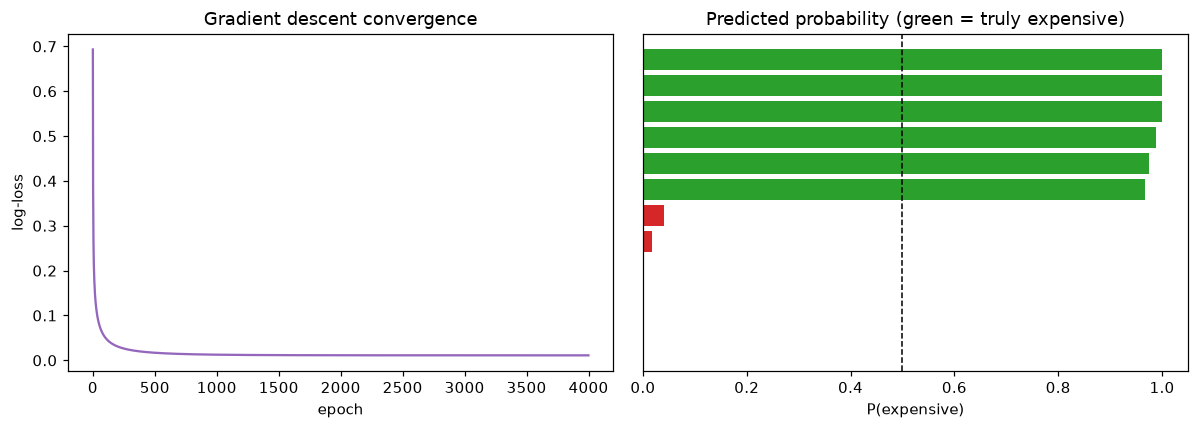

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].plot(loss_history, color="tab:purple")
axes[0].set_xlabel("epoch"); axes[0].set_ylabel("log-loss")
axes[0].set_title("Gradient descent convergence")

order = np.argsort(probs)
colors = ["tab:red" if v == 0 else "tab:green" for v in y_class[order]]
axes[1].barh(range(n), probs[order], color=colors)
axes[1].axvline(0.5, ls="--", color="black", lw=1)
axes[1].set_xlabel("P(expensive)"); axes[1].set_yticks([])
axes[1].set_title("Predicted probability (green = truly expensive)")

plt.tight_layout(); plt.show()

### What the two models share

Both compute exactly the same object: a **dot product** $s = w \cdot x$, i.e. a linear score.

- Regression uses $s$ directly as the prediction.
- Classification passes $s$ through a sigmoid and thresholds it. The decision boundary
  $\{x : w \cdot x = 0\}$ is a **hyperplane** in $\mathbb{R}^d$.

The geometry is identical; only the loss function and the output interpretation differ. This is why
both are called *linear models*.

Note also that the accuracy above is on the training data with 12 samples and 7 parameters — the
perfect score is a sign of overfitting, not of a good model. A real evaluation needs held-out data.

---
## Part 3 — Linear transformations and matrix–vector operations

A linear map $T(x) = Mx$ sends $\mathbb{R}^d \to \mathbb{R}^k$. Applied to the whole dataset at once:

$$X_{\text{new}} = X M^\top \qquad (n,d) \times (d,k) \to (n,k)$$

Below: centering, scaling, rotation, projection — and what each one preserves or destroys.

### 3a. Centering — a shift, expressible as a matrix

Subtracting the mean vector moves the centroid of the point cloud to the origin. Broadcasting does
it directly, but it can equally be written as multiplication by the **centering matrix**
$H = I - \frac{1}{n}\mathbf{1}\mathbf{1}^\top$, which is symmetric and *idempotent* ($H^2 = H$) —
centering already-centered data changes nothing.

In [19]:
mean_vec = X.mean(axis=0)
Xc = X - mean_vec                      # broadcasting

H = np.eye(n) - np.ones((n, n)) / n    # (n, n) centering matrix

print("centroid:", mean_vec)
print("column means after centering (~0):", Xc.mean(axis=0))
print("H is idempotent  (H @ H == H):", np.allclose(H @ H, H))
print("H is symmetric:", np.allclose(H, H.T))
print("H @ X reproduces X - mean:", np.allclose(H @ X, Xc))

centroid: [79.5    2.917 16.833  0.417  0.333  0.25 ]
column means after centering (~0): [ 0.  0.  0. -0.  0.  0.]
H is idempotent  (H @ H == H): True
H is symmetric: True
H @ X reproduces X - mean: True


### 3b. Scaling — a diagonal matrix

Dividing each feature by its standard deviation is multiplication by $D = \operatorname{diag}(1/\sigma)$.
So standardisation is exactly *center, then apply a diagonal linear map*.

In [20]:
D = np.diag(1.0 / sigma)               # (d, d)
print("Xc @ D reproduces the standardised matrix:", np.allclose(Xc @ D, Xs))

Xc @ D reproduces the standardised matrix: True


### 3c. Rotation — an orthogonal matrix

An orthogonal $R$ ($R^\top R = I$, $\det R = 1$) is a **rigid motion**: it preserves every length,
every angle and every pairwise distance. Since nearest-neighbour methods and any distance-based
model see only those quantities, such models are completely unaffected by rotating the data.

In [21]:
theta = np.pi / 6                                  # 30 degrees
R2 = np.array([[np.cos(theta), -np.sin(theta)],
               [np.sin(theta),  np.cos(theta)]])
R = np.eye(d)
R[:2, :2] = R2                                     # rotate the (area, rooms) plane

Xr = Xs @ R.T

print("R^T R == I :", np.allclose(R.T @ R, np.eye(d)))
print("det(R) =", round(float(np.linalg.det(R)), 6))
print("lengths preserved :", np.allclose(np.linalg.norm(Xs, axis=1), np.linalg.norm(Xr, axis=1)))
print("pairwise distances preserved:",
      np.allclose(np.linalg.norm(Xs[0] - Xs[1]), np.linalg.norm(Xr[0] - Xr[1])))

R^T R == I : True
det(R) = 1.0
lengths preserved : True
pairwise distances preserved: True


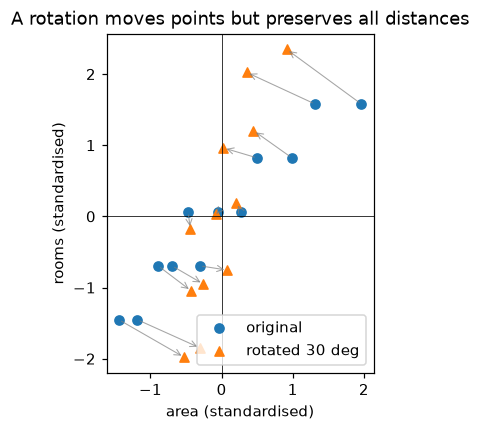

In [22]:
fig, ax = plt.subplots()
ax.scatter(Xs[:, 0], Xs[:, 1], label="original", c="tab:blue")
ax.scatter(Xr[:, 0], Xr[:, 1], label="rotated 30 deg", c="tab:orange", marker="^")
for a, b in zip(Xs[:, :2], Xr[:, :2]):
    ax.annotate("", xy=b, xytext=a,
                arrowprops=dict(arrowstyle="->", color="grey", lw=.7, alpha=.7))
ax.axhline(0, lw=.5, color="k"); ax.axvline(0, lw=.5, color="k")
ax.set_xlabel("area (standardised)"); ax.set_ylabel("rooms (standardised)")
ax.set_title("A rotation moves points but preserves all distances")
ax.set_aspect("equal"); ax.legend()
plt.show()

### 3d. Projection — PCA via the SVD

Write $X_s = U \Sigma V^\top$. The columns of $V$ are the **principal directions**, ordered by how
much variance they capture. Taking the first $k$ gives a matrix $W \in \mathbb{R}^{d \times k}$ and a
rank-$k$ linear map:

$$Z = X_s W \quad (\text{compress to } \mathbb{R}^k), \qquad \hat{X} = Z W^\top \quad (\text{reconstruct})$$

The composition $P = WW^\top$ is a **projection matrix**: symmetric, idempotent, rank $k$. Unlike a
rotation this map is *not* invertible — information orthogonal to the subspace is discarded, which is
exactly what makes it dimensionality reduction.

In [23]:
U, S, Vt = np.linalg.svd(Xs, full_matrices=False)
explained = S ** 2 / np.sum(S ** 2)

k = 2
W = Vt[:k].T                           # (d, k) basis of the subspace
Z = Xs @ W                             # (n, k) compressed coordinates
X_rec = Z @ W.T                        # (n, d) reconstruction
P = W @ W.T                            # (d, d) projection matrix

print("singular values:", S)
print("explained variance ratio:", explained.round(3))
print("cumulative:", np.cumsum(explained).round(3))
print("\nreconstruction error ||Xs - X_rec||_F =", round(float(np.linalg.norm(Xs - X_rec)), 4))
print("P idempotent (P@P == P):", np.allclose(P @ P, P))
print("P symmetric:", np.allclose(P, P.T))
print("rank(P) =", np.linalg.matrix_rank(P), "(equals k)")

singular values: [5.817 4.928 3.474 1.267 0.445 0.   ]
explained variance ratio: [0.47  0.337 0.168 0.022 0.003 0.   ]
cumulative: [0.47  0.807 0.975 0.997 1.    1.   ]

reconstruction error ||Xs - X_rec||_F = 3.7247
P idempotent (P@P == P): True
P symmetric: True
rank(P) = 2 (equals k)


The last singular value is 0 — that is the dummy-variable dependency from Part 1 showing up
geometrically. The data does not actually fill $\mathbb{R}^6$; it lies in a 5-dimensional subspace.

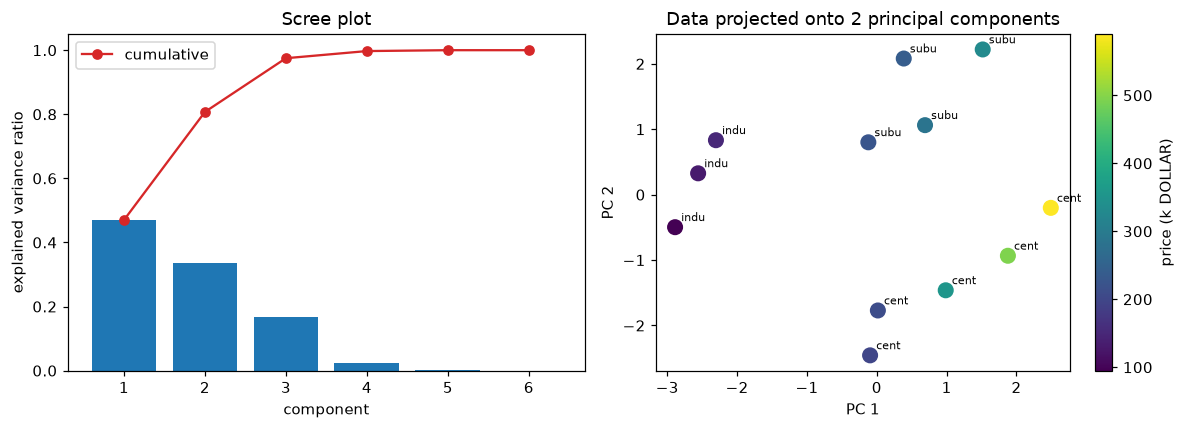

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].bar(range(1, len(S) + 1), explained, color="tab:blue")
axes[0].plot(range(1, len(S) + 1), np.cumsum(explained), "o-", color="tab:red", label="cumulative")
axes[0].set_xlabel("component"); axes[0].set_ylabel("explained variance ratio")
axes[0].set_title("Scree plot"); axes[0].legend()

sc = axes[1].scatter(Z[:, 0], Z[:, 1], c=y_price, s=90, cmap="viridis")
for i, (a, b) in enumerate(Z):
    axes[1].annotate(RAW[i][3][:4], (a, b), fontsize=7,
                     xytext=(4, 4), textcoords="offset points")
axes[1].set_xlabel("PC 1"); axes[1].set_ylabel("PC 2")
axes[1].set_title("Data projected onto 2 principal components")
plt.colorbar(sc, ax=axes[1], label="price (k DOLLAR)")

plt.tight_layout(); plt.show()

### 3e. Covariance and Gram matrices

Two different products of the same matrix, answering two different questions:

$$C = \tfrac{1}{n-1} X_c^\top X_c \in \mathbb{R}^{d \times d} \quad \text{(how features co-vary)}$$
$$G = X_s X_s^\top \in \mathbb{R}^{n \times n} \quad \text{(how similar samples are: } G_{ij} = \langle x_i, x_j \rangle)$$

$C$ drives PCA; $G$ is the object that kernel methods generalise. Both are symmetric positive
semi-definite, and they share the same non-zero eigenvalues.

In [25]:
C = Xc.T @ Xc / (n - 1)                # (d, d)
G = Xs @ Xs.T                          # (n, n)

print("eigenvalues of Xs^T Xs :", np.sort(np.linalg.eigvalsh(Xs.T @ Xs))[::-1].round(4))
print("eigenvalues of Xs Xs^T :", np.sort(np.linalg.eigvalsh(G))[::-1][:d].round(4))
print("squared singular values:", (S ** 2).round(4))
print("\n-> the same numbers, three ways of computing them")

pd.DataFrame(C, index=FEATURE_NAMES, columns=FEATURE_NAMES).round(2)

eigenvalues of Xs^T Xs : [33.837 24.29  12.069  1.606  0.198 -0.   ]
eigenvalues of Xs Xs^T : [33.837 24.29  12.069  1.606  0.198  0.   ]
squared singular values: [33.837 24.29  12.069  1.606  0.198  0.   ]

-> the same numbers, three ways of computing them


,area_m2,rooms,age_yrs,is_center,is_suburb,is_industrial
area_m2,1034.27,42.59,-104.73,2.32,5.00,-7.32
rooms,42.59,1.90,-1.29,0.04,0.21,-0.25
age_yrs,-104.73,-1.29,165.97,-4.92,0.42,4.50
is_center,2.32,0.04,-4.92,0.27,-0.15,-0.11
is_suburb,5.00,0.21,0.42,-0.15,0.24,-0.09
is_industrial,-7.32,-0.25,4.50,-0.11,-0.09,0.20


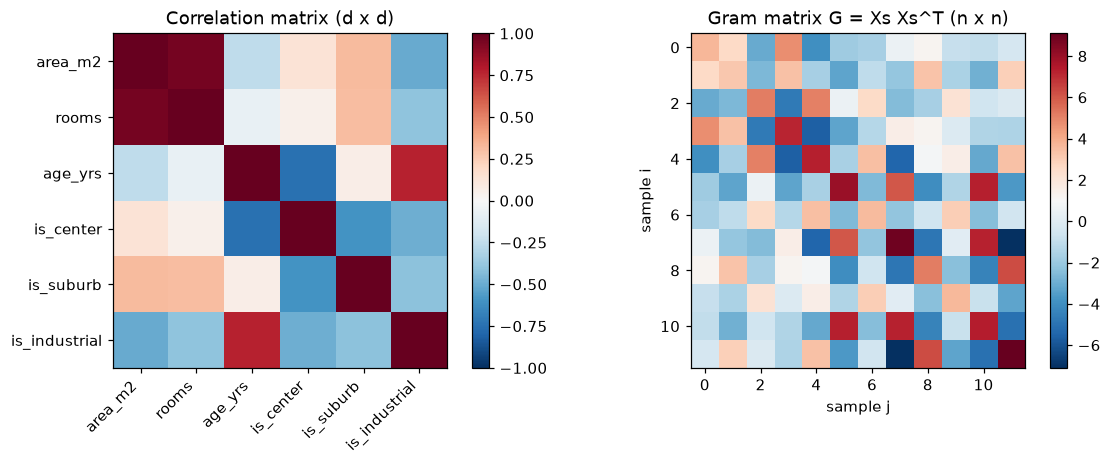

In [26]:
Cs = np.corrcoef(Xs, rowvar=False)     # correlation = covariance of standardised data

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
im0 = axes[0].imshow(Cs, cmap="RdBu_r", vmin=-1, vmax=1)
axes[0].set_xticks(range(d)); axes[0].set_xticklabels(FEATURE_NAMES, rotation=45, ha="right")
axes[0].set_yticks(range(d)); axes[0].set_yticklabels(FEATURE_NAMES)
axes[0].set_title("Correlation matrix (d x d)")
plt.colorbar(im0, ax=axes[0])

im1 = axes[1].imshow(G, cmap="RdBu_r")
axes[1].set_title("Gram matrix G = Xs Xs^T (n x n)")
axes[1].set_xlabel("sample j"); axes[1].set_ylabel("sample i")
plt.colorbar(im1, ax=axes[1])

plt.tight_layout(); plt.show()

### 3f. Does the linear model care about these transformations?

Ordinary least squares is **equivariant** under an invertible linear reparametrisation of the
features. Replacing $\Phi$ by $\Phi M$ leaves the *column space* unchanged, so the fitted hyperplane —
and every prediction — is identical. Only the coordinates of $w$ change.

The practical reading: for OLS, feature scaling is cosmetic. It matters for *regularised* models
(the penalty $\lVert w \rVert^2$ is tied to a coordinate system, so ridge is **not** equivariant) and
for *gradient descent* (it reshapes the loss surface and changes convergence speed).
> **Note the estimator change.** The cell below uses `np.linalg.lstsq`, not `fit_ridge` — this is
> the only place in the notebook fitting **pure OLS**, with no penalty. It survives the singular
> $\Phi^\top\Phi$ (the dummy-variable dependency from Part 1) because `lstsq` works through the SVD
> and returns the *minimum-norm* solution instead of inverting anything. So the notebook now shows
> three ways to fit the same linear model: `solve` on the ridge-stabilised normal equations,
> `fit_ridge` as a reusable function, and `lstsq` via the SVD.

In [27]:
M = np.eye(d) * 2.0
M[0, 1] = 0.5                                        # invertible, non-orthogonal
print("det(M) =", round(float(np.linalg.det(M)), 3), "-> invertible")

# exact least squares on both sides (no ridge term, which would break equivariance)
w_plain, *_ = np.linalg.lstsq(Phi, y_price, rcond=None)
Phi_M = add_bias(Xs @ M)
w_M, *_ = np.linalg.lstsq(Phi_M, y_price, rcond=None)

print("max |y_hat - y_hat_M| =",
      float(np.max(np.abs(Phi @ w_plain - Phi_M @ w_M))))
print("\nsame predictions, different weights:")
print("  original       :", w_plain[1:3].round(3))
print("  reparametrised :", w_M[1:3].round(3))

det(M) = 64.0 -> invertible
max |y_hat - y_hat_M| = 2.2737367544323206e-13

same predictions, different weights:
  original       : [168.584 -49.219]
  reparametrised : [ 90.444 -24.609]


---
## Putting it together: a new record through both models

The full pipeline for unseen data — encode with the *same* vocabulary, standardise with the *training*
$\mu$ and $\sigma$ (not recomputed on the new point), add the bias, then take a dot product.

In [28]:
new_record = (82.0, 3, 7, "center")

x_new = encode(new_record)                    # raw -> feature vector
x_new_s = (x_new - mu) / sigma                # reuse TRAINING mu, sigma
phi_new = np.concatenate([[1.0], x_new_s])    # add bias

score_reg = phi_new @ w_reg
score_cls = phi_new @ w_cls

print("raw record  :", new_record)
print("feature vec :", x_new)
print("standardised:", x_new_s.round(3))
print(f"\nregression     -> price ~ {score_reg:.1f} k DOLLAR")
print(f"classification -> P(expensive) = {sigmoid(score_cls):.3f} "
      f"-> class {int(sigmoid(score_cls) >= 0.5)}")

raw record  : (82.0, 3, 7, 'center')
feature vec : [82.  3.  7.  1.  0.  0.]
standardised: [ 0.081  0.063 -0.797  1.183 -0.707 -0.577]

regression     -> price ~ 352.9 k DOLLAR
classification -> P(expensive) = 0.978 -> class 1


---
## Summary

| concept | operation | shape | key property |
|---|---|---|---|
| feature vector | `encode(record)` | $(d,)$ | numeric + one-hot |
| design matrix | `np.vstack(...)` | $(n,d)$ | row = sample |
| bias trick | `add_bias` | $(n,d{+}1)$ | intercept as a weight |
| prediction | `Phi @ w` | $(n,)$ | matrix–vector product |
| normal equations | `solve(Phi.T@Phi, Phi.T@y)` | $(d{+}1,)$ | closed-form OLS |
| logistic gradient | `Phi.T @ (p - y) / n` | $(d{+}1,)$ | iterative fit |
| centering | `H @ X` | $(n,d)$ | $H^2 = H$ |
| scaling | `Xc @ D` | $(n,d)$ | diagonal |
| rotation | `Xs @ R.T` | $(n,d)$ | $R^\top R = I$, isometry |
| projection | `Xs @ W` | $(n,k)$ | $P^2 = P$, lossy |
| covariance | `Xc.T @ Xc / (n-1)` | $(d,d)$ | feature relationships |
| Gram | `Xs @ Xs.T` | $(n,n)$ | sample similarities |

**The one sentence version:** a dataset is a matrix, a model is a vector, a prediction is a dot
product, and preprocessing is a change of basis.

### Things to try
- Change `threshold` from the median to a fixed value (e.g. 300) and watch the class balance — and the accuracy — shift.
- Drop one one-hot column and confirm the smallest singular value stops being zero.
- Set `k = 1` in the PCA section and see the reconstruction error rise.
- Skip standardisation and refit the logistic model: same optimum, far more epochs to reach it.